# 2.2 Calibration as optimization

Every climate model carries parameters that stand in for unresolved physics — here, the
diffusivity $D$ and the ice albedo $\alpha_i$. Choosing them to match observations is
**calibration** (the term *tuning* is also used, usually with some embarrassment). With
a differentiable model, calibration becomes ordinary optimization: write down a misfit
between model and observations, and descend its gradient.

This chapter calibrates the Budyko–Sellers model in a **perfect-model experiment**: the
"observations" are produced by the model itself with known parameters, plus noise. That
is the honest way to develop a method — the answer is known, so failure is visible —
with the equally honest caveat that it hides the hardest part of real calibration,
structural error (no parameter setting of a wrong model reproduces the truth).

```{admonition} Learning goals
:class: tip
- Set up a perfect-model calibration experiment and state what it does and does not test
- Minimize a model-observation misfit with gradient descent (`optax`)
- Read a loss landscape: curvature, parameter compensation, and the noise floor
- Weigh gradient-based against ensemble calibration methods
```

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)   # climate work needs double precision
# Running on Colab? First run:  %pip install -q optax equinox diffrax

In [2]:
# --- The Budyko-Sellers model (defined in Chapter 2.1; repeated so this notebook is self-contained)
N_LAT = 60
x_edge = jnp.linspace(-1.0, 1.0, N_LAT + 1)      # cell edges in x = sin(latitude)
x = 0.5 * (x_edge[:-1] + x_edge[1:])             # cell centres (an equal-area grid)
dx = 2.0 / N_LAT
lat = jnp.rad2deg(jnp.arcsin(x))                 # centre latitudes (degrees)

Q = 340.25              # global-mean insolation S0/4, W m^-2
s_x = 1.0 - 0.482 * 0.5 * (3.0 * x**2 - 1.0)     # annual-mean insolation shape s(x)
A_olr = 203.3           # outgoing longwave radiation at 0 degC, W m^-2
B_olr = 2.09            # longwave feedback, W m^-2 K^-1
heat_capacity = 4.0e7   # J m^-2 K^-1 (~10 m of water)
dt = 21600.0            # 6-hour time step, s

default_params = {"D": 0.48, "albedo_warm": 0.32, "albedo_ice": 0.62}

def albedo(T, p):
    ice_fraction = 0.5 * (1.0 - jnp.tanh((T + 10.0) / 2.0))    # ice below about -10 degC
    return p["albedo_warm"] + (p["albedo_ice"] - p["albedo_warm"]) * ice_fraction

def energy_tendency(T, p, forcing=0.0):
    """Net energy input at each latitude (W m^-2), for temperature T in degC."""
    absorbed = Q * s_x * (1.0 - albedo(T, p))
    emitted = A_olr + B_olr * T
    flux = p["D"] * (1.0 - x_edge[1:-1] ** 2) * jnp.diff(T) / dx   # poleward heat flux
    flux = jnp.concatenate([jnp.zeros(1), flux, jnp.zeros(1)])     # no flux through the poles
    transport = jnp.diff(flux) / dx
    return absorbed - emitted + transport + forcing

def integrate(T0, p, forcing=0.0, n_years=30):
    """Step the model forward and return the final temperature profile."""
    n_steps = int(n_years * 365.25 * 86400 / dt)
    def step(T, _):
        return T + dt / heat_capacity * energy_tendency(T, p, forcing), None
    T_final, _ = jax.lax.scan(step, T0, None, length=n_steps)
    return T_final

T_start = 15.0 - 25.0 * 0.5 * (3.0 * x**2 - 1.0)    # smooth warm initial profile

## Synthetic observations

Truth: the default parameters ($D = 0.48$, $\alpha_i = 0.62$). The observations are the
truth's equilibrium zonal-mean temperature profile with 1 K of independent noise at
each latitude — a caricature of an observed climatology:

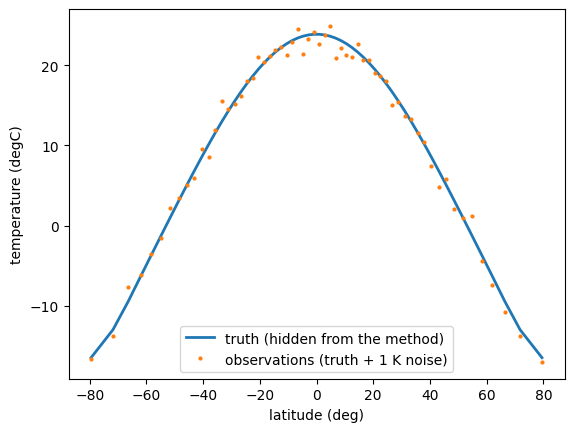

In [3]:
true_params = dict(default_params)
key = jax.random.key(0)
T_true = integrate(T_start, true_params)
T_obs = T_true + 1.0 * jax.random.normal(key, T_true.shape)

plt.plot(lat, T_true, lw=2, label="truth (hidden from the method)")
plt.plot(lat, T_obs, ".", ms=4, label="observations (truth + 1 K noise)")
plt.xlabel("latitude (deg)"); plt.ylabel("temperature (degC)"); plt.legend()
plt.show()

## Misfit and its gradient

The misfit is a mean-square difference between the model's equilibrium profile and the
observations, as a function of the two parameters being calibrated. Before any
optimization: check the gradient. This takes four extra lines and has caught more bugs
than any other habit in this book:

In [4]:
def loss(theta):
    p = dict(true_params, D=theta[0], albedo_ice=theta[1])
    T = integrate(T_start, p)
    return jnp.mean((T - T_obs) ** 2)

theta0 = jnp.array([0.40, 0.55])          # a deliberately wrong first guess
g = jax.grad(loss)(theta0)
for i, name in enumerate(["D", "albedo_ice"]):
    bump = jnp.zeros(2).at[i].set(1e-5)
    fd = (loss(theta0 + bump) - loss(theta0 - bump)) / 2e-5
    print(f"dJ/d({name}):  autodiff {float(g[i]):9.4f}   finite difference {float(fd):9.4f}")

dJ/d(D):  autodiff  -71.3768   finite difference  -71.3768
dJ/d(albedo_ice):  autodiff   42.3577   finite difference   42.3577


## Descending

`optax` provides the optimizers familiar from machine learning; each iteration runs the
full 30-year model spin-up and differentiates through it. Adam with a decaying step
handles the difference in scale between the two parameters without manual
preconditioning:

recovered: D = 0.472, albedo_ice = 0.605
truth:     D = 0.480, albedo_ice = 0.620
final loss 1.179 vs observation noise variance 1.0


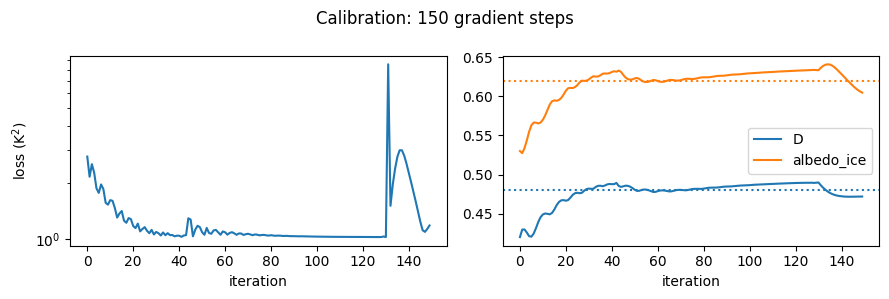

In [5]:
import optax

opt = optax.adam(optax.exponential_decay(2e-2, transition_steps=50, decay_rate=0.5))
state = opt.init(theta0)
value_and_grad = jax.jit(jax.value_and_grad(loss))

theta, history = theta0, []
for i in range(150):
    L, g = value_and_grad(theta)
    updates, state = opt.update(g, state)
    theta = optax.apply_updates(theta, updates)
    history.append([float(L), float(theta[0]), float(theta[1])])

import numpy as np
history = np.array(history)
print(f"recovered: D = {theta[0]:.3f}, albedo_ice = {theta[1]:.3f}")
print(f"truth:     D = {true_params['D']:.3f}, albedo_ice = {true_params['albedo_ice']:.3f}")
print(f"final loss {history[-1,0]:.3f} vs observation noise variance 1.0")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.semilogy(history[:, 0]); ax1.set_xlabel("iteration"); ax1.set_ylabel("loss (K$^2$)")
ax2.plot(history[:, 1], label="D"); ax2.plot(history[:, 2], label="albedo_ice")
ax2.axhline(0.48, color="C0", ls=":"); ax2.axhline(0.62, color="C1", ls=":")
ax2.set_xlabel("iteration"); ax2.legend()
fig.suptitle("Calibration: 150 gradient steps"); plt.tight_layout(); plt.show()

Both parameters are recovered to a few percent, and — a detail worth internalizing —
the loss flattens just above the observation-noise variance (1 K²). A loss well
above the noise floor means the model cannot fit the data; a loss *below* it means the
method has started fitting the noise. Knowing where the floor is turns the loss value
itself into a diagnostic.

## The loss landscape

Two parameters permit a luxury unavailable in high dimensions: evaluating the loss
everywhere. The landscape explains the optimizer's behavior and previews concepts that
matter when there are thousands of parameters:

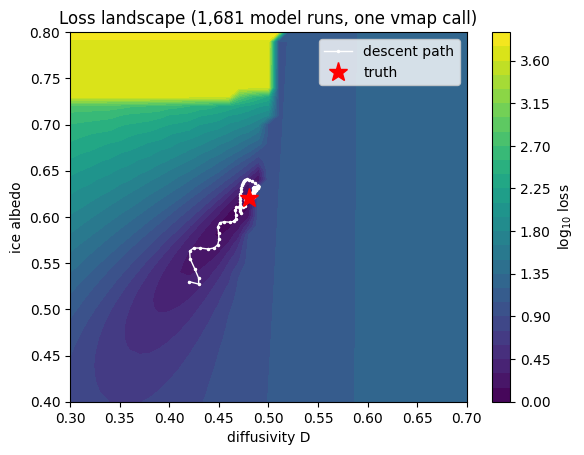

In [6]:
D_grid = jnp.linspace(0.30, 0.70, 41)
ai_grid = jnp.linspace(0.40, 0.80, 41)
DD, AI = jnp.meshgrid(D_grid, ai_grid)
L_grid = jax.jit(jax.vmap(jax.vmap(lambda d, a: loss(jnp.array([d, a])))))(DD, AI)

plt.contourf(DD, AI, jnp.log10(L_grid), levels=25)
plt.colorbar(label="log$_{10}$ loss")
plt.plot(history[:, 1], history[:, 2], "w.-", ms=3, lw=1, label="descent path")
plt.plot(0.48, 0.62, "r*", ms=14, label="truth")
plt.xlabel("diffusivity D"); plt.ylabel("ice albedo")
plt.legend(); plt.title("Loss landscape (1,681 model runs, one vmap call)")
plt.show()

Two features deserve names. The minimum sits in a curved **valley**: along its floor,
increasing $D$ (more heat to the pole, smaller ice cap) can be partly traded against
increasing $\alpha_i$ (brighter ice) with little change in misfit. This *parameter
compensation* is ubiquitous in real model tuning, and its high-dimensional analogue —
long flat valleys — is why converged parameters should never be over-interpreted
individually. Second, the landscape steepens dramatically toward low $D$ / high
$\alpha_i$: there the ice cap runs away toward an ice-covered planet — a reminder that
parameter space contains different climate *regimes*, not just different fits.

## Gradients or ensembles?

The community's standard tools for this problem — ensemble Kalman methods and related
derivative-free schemes {cite}`schneider2017earth` — estimate the descent direction
statistically from tens to hundreds of perturbed model runs. The comparison is not
one-sided:

- **Cost.** A gradient step costs a few model runs regardless of parameter count;
  ensemble methods need ensembles comparable to the number of effective parameters.
  With two parameters this is a wash. With a $10^5$-parameter neural network closure
  (Chapter 2.4) it is decisive — there is no ensemble version of deep learning.
- **Robustness.** Ensembles average over roughness and need no derivative to exist;
  gradients require the loss to be smooth, which Chapters 3.1 and 3.3 show is a real
  constraint (chaos, thresholds).
- **Uncertainty.** An ensemble gives a spread for free; a gradient gives a point
  estimate (though the loss curvature — one more autodiff call — recovers local
  uncertainty).

**Exercises.**
1. Calibrate with observations only equatorward of 60° (mask the loss). Where does the
   recovered $\alpha_i$ end up, and why does the valley direction predict this?
2. Add $A$ (the longwave constant) as a third parameter. Does the noise-floor loss
   change? Are the parameters still identifiable?
3. Replace Adam with plain gradient descent (`optax.sgd`). What learning rate is
   needed, and why is it so different in the two parameter directions?